In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

### Loading Dataset

In [36]:
wine_data = pd.read_csv('wine_quality.csv')

### Check how the data is distributed

In [37]:
wine_data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


### Information about the data columns

In [38]:
wine_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [39]:
wine_data['quality'].value_counts().sort_index()

quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64

### How the data columns are distributed?

### Distribution of quality labels

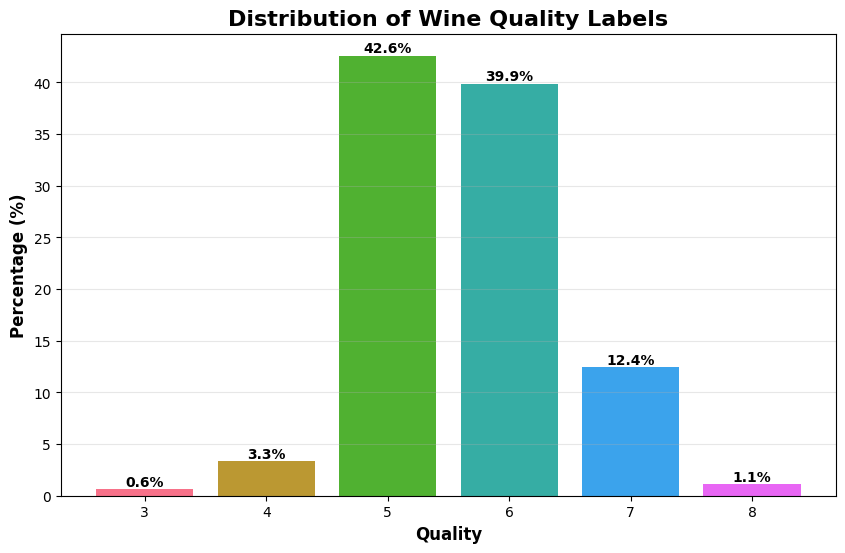

In [40]:
quality_counts = wine_data['quality'].value_counts().sort_index()

quality_percentages = (quality_counts / quality_counts.sum()) * 100

# Create a bar chart
plt.figure(figsize=(10, 6))
bars = plt.bar(quality_percentages.index, quality_percentages.values, 
               color=sns.color_palette('husl', len(quality_percentages)))

# Add percentage labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.1f}%',
             ha='center', va='bottom', fontweight='bold')

plt.xlabel('Quality', fontsize=12, fontweight='bold')
plt.ylabel('Percentage (%)', fontsize=12, fontweight='bold')
plt.title('Distribution of Wine Quality Labels', fontsize=16, fontweight='bold')
plt.xticks(quality_percentages.index)
plt.grid(axis='y', alpha=0.3)
plt.show()

<Axes: xlabel='quality', ylabel='fixed acidity'>

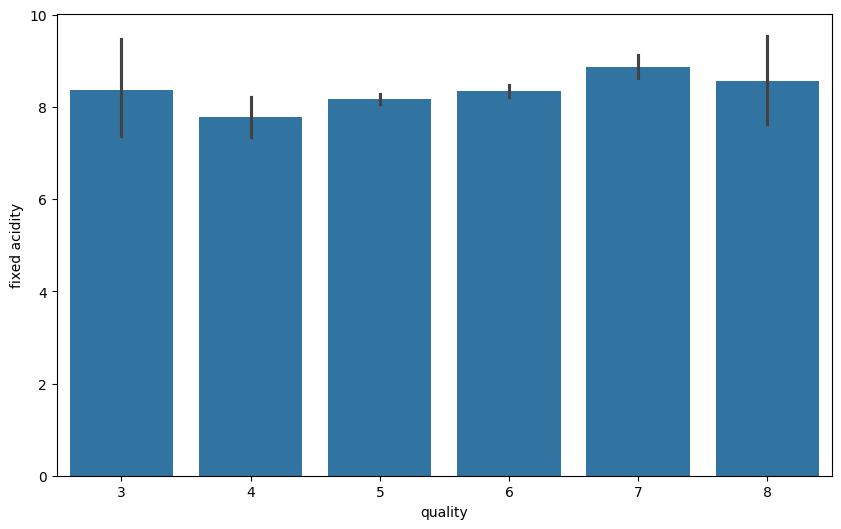

In [41]:
fig = plt.figure(figsize = (10,6))
sns.barplot(x = 'quality', y = 'fixed acidity', data = wine_data)


`Fixed acity does not give any specification to classify the quality`

<Axes: xlabel='quality', ylabel='volatile acidity'>

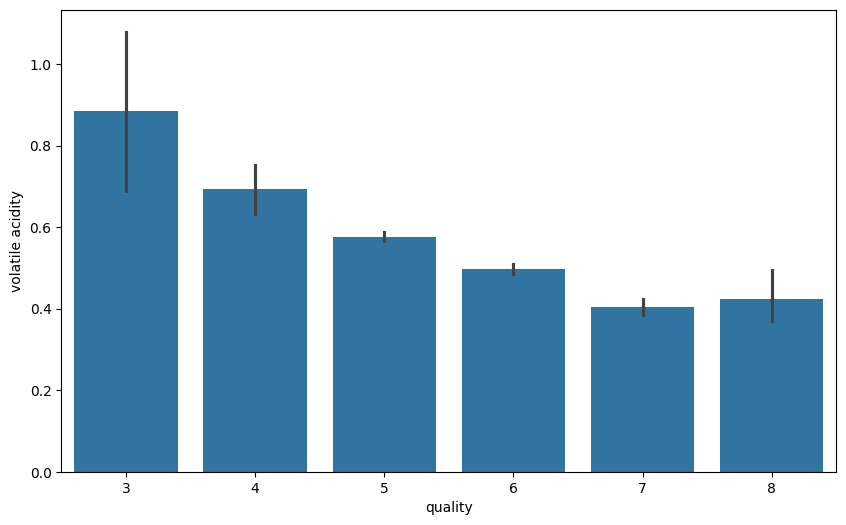

In [42]:
fig = plt.figure(figsize = (10,6))
sns.barplot(x = 'quality', y = 'volatile acidity', data = wine_data)


`Quite a downing trend in the volatile acidy as we go higher the quality`

<Axes: xlabel='quality', ylabel='citric acid'>

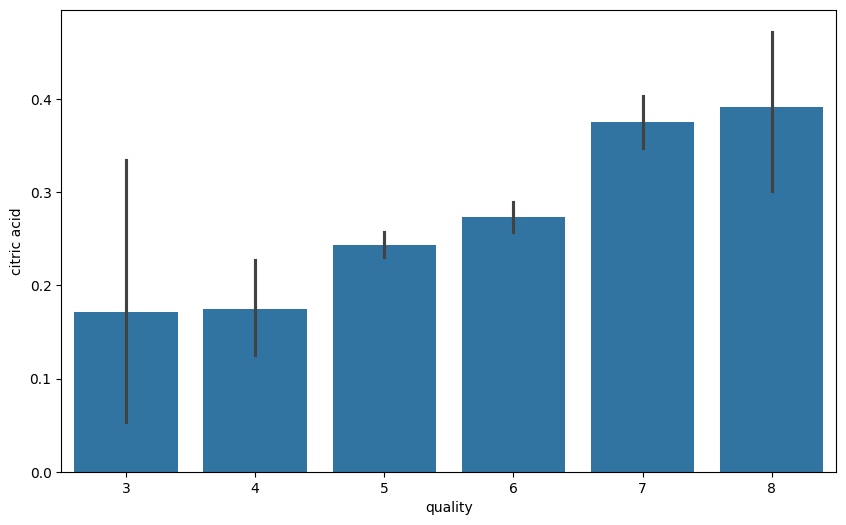

In [43]:
fig = plt.figure(figsize = (10,6))
sns.barplot(x = 'quality', y = 'citric acid', data = wine_data)


`Citric acid go higher as we go higher in the quality of the wine`

<Axes: xlabel='quality', ylabel='residual sugar'>

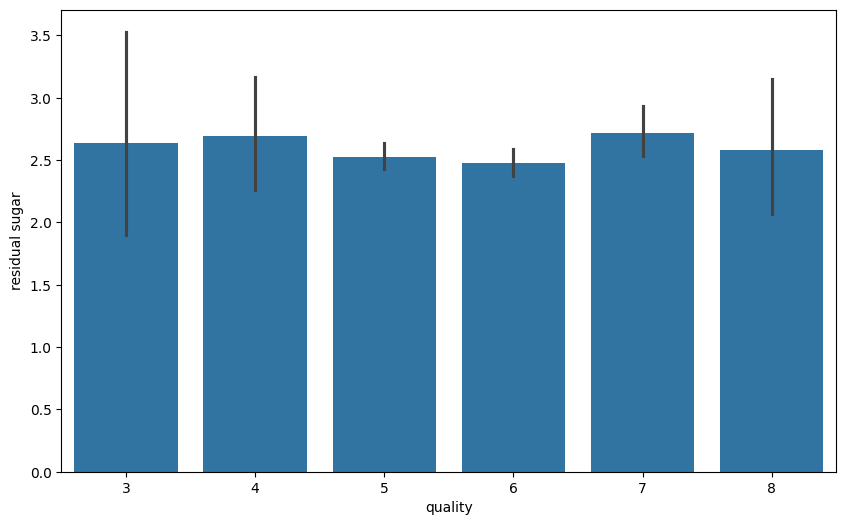

In [44]:
fig = plt.figure(figsize = (10,6))
sns.barplot(x = 'quality', y = 'residual sugar', data = wine_data)


`Residual sugar does not give any specification to classify the quality`

<Axes: xlabel='quality', ylabel='chlorides'>

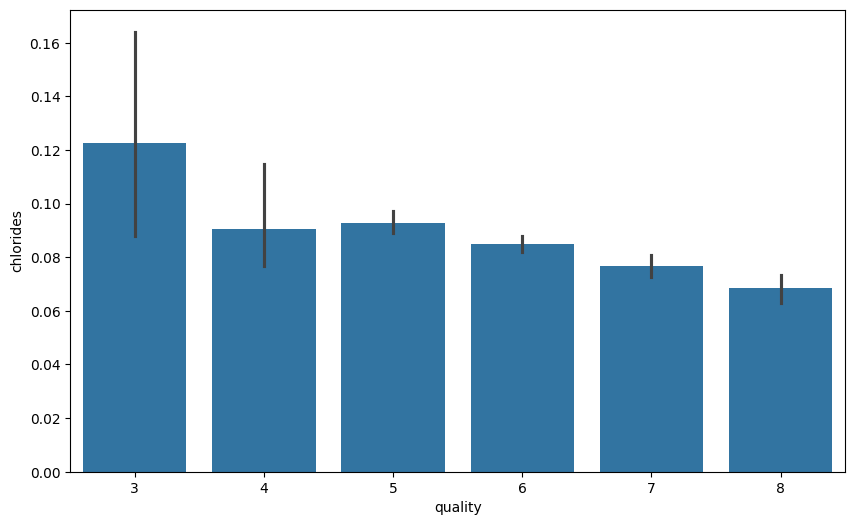

In [45]:
fig = plt.figure(figsize = (10,6))
sns.barplot(x = 'quality', y = 'chlorides', data = wine_data)


`Composition of chloride also go down as we go higher in the quality of the wine`

<Axes: xlabel='quality', ylabel='free sulfur dioxide'>

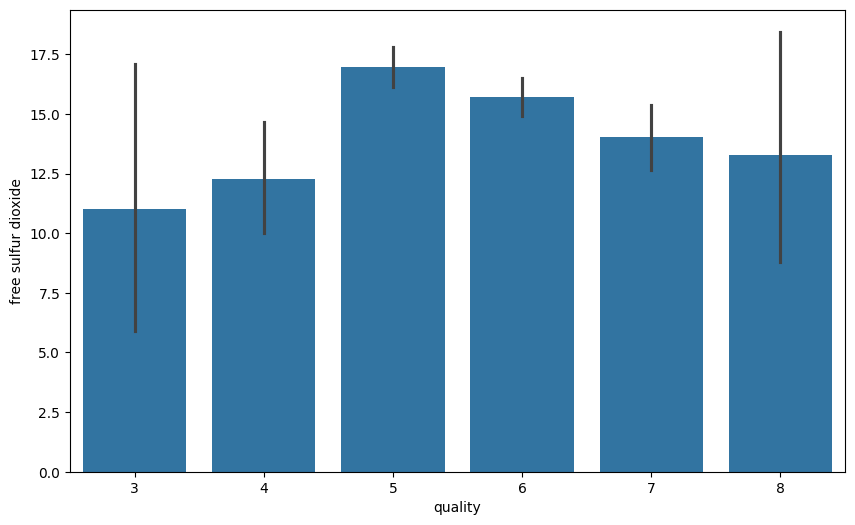

In [46]:
fig = plt.figure(figsize = (10,6))
sns.barplot(x = 'quality', y = 'free sulfur dioxide', data = wine_data)


<Axes: xlabel='quality', ylabel='total sulfur dioxide'>

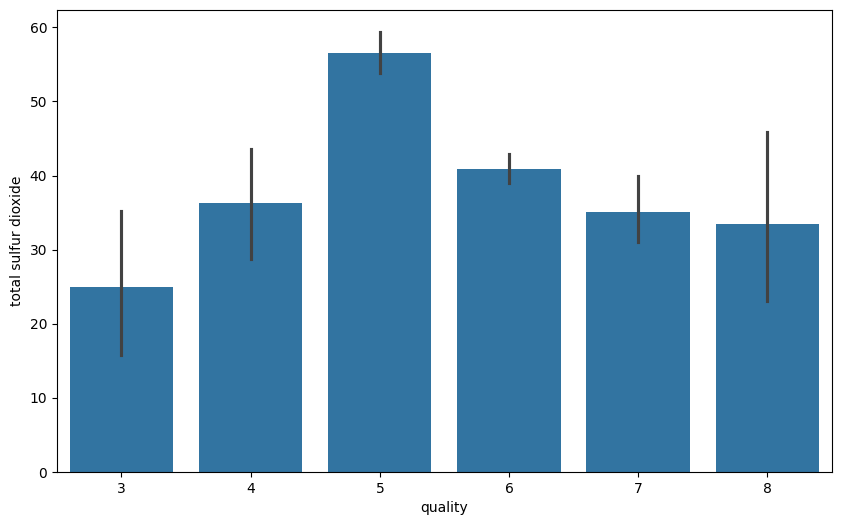

In [47]:
fig = plt.figure(figsize = (10,6))
sns.barplot(x = 'quality', y = 'total sulfur dioxide', data = wine_data)


<Axes: xlabel='quality', ylabel='density'>

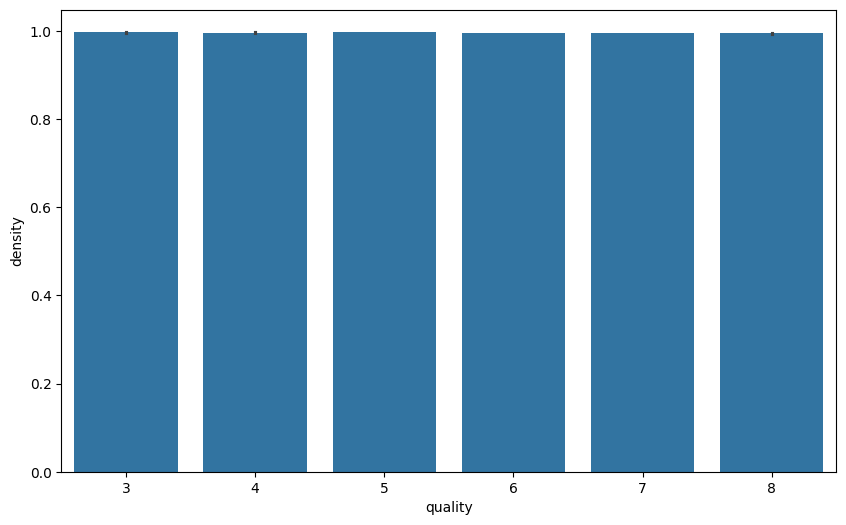

In [48]:
fig = plt.figure(figsize = (10,6))
sns.barplot(x = 'quality', y = 'density', data = wine_data)


<Axes: xlabel='quality', ylabel='pH'>

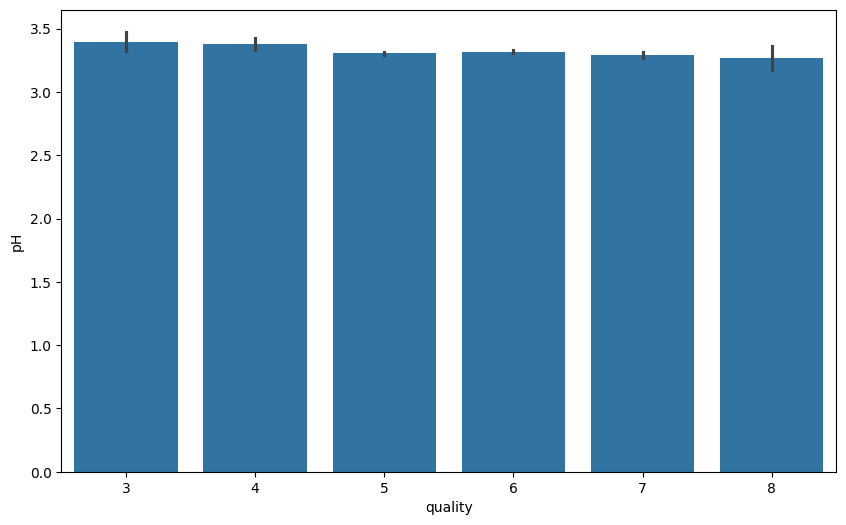

In [49]:
fig = plt.figure(figsize = (10,6))
sns.barplot(x = 'quality', y = 'pH', data = wine_data)


<Axes: xlabel='quality', ylabel='sulphates'>

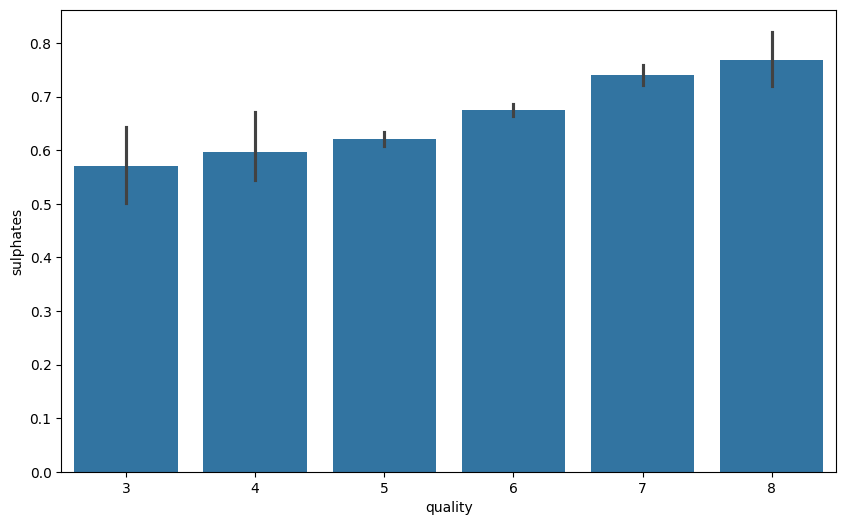

In [50]:
fig = plt.figure(figsize = (10,6))
sns.barplot(x = 'quality', y = 'sulphates', data = wine_data)


`Sulphates level goes higher with the quality of wine`

<Axes: xlabel='quality', ylabel='alcohol'>

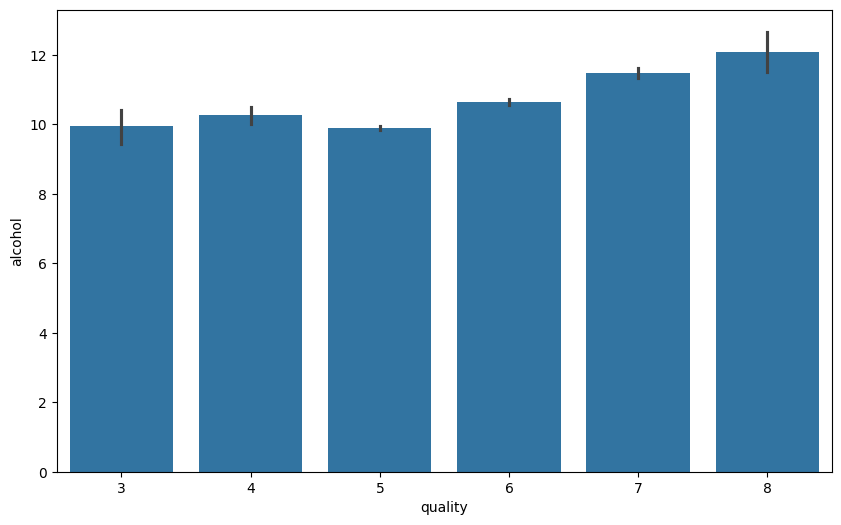

In [51]:
fig = plt.figure(figsize = (10,6))
sns.barplot(x = 'quality', y = 'alcohol', data = wine_data)


`Alcohol level also goes higher as te quality of wine increases`

#### Process Data

In [ ]:
# 1. Criar a classificação binária baseada na regra:
# quality <= 5 -> 'under-average'
# quality >= 6 -> 'above-average'
wine_data['quality_category'] = wine_data['quality'].apply(lambda x: 'above-average' if x >= 6 else 'under-average')

